<a href="https://colab.research.google.com/github/therokitoki/AA2_TP_Alsop-Hachen-Nemeth/blob/main/TP2/tp2_ejercicio1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Practico N°2 AAII

Alumnos: Agustin Alsop, Rocio Hachen, Ulises Nemeth

## Ejercicio 1

### Descripción:
En este problema, se presenta un conjunto de datos que contiene clips de audio correspondientes a dígitos hablados del 0 al 9.

### Dataset:
https://www.tensorflow.org/datasets/catalog/spoken_digit

El dataset proporcionado incluye un total de 2500 clips de audio correspondientes a 5 locutores distintos, 50 clips por dígito por locutor.

### Objetivo:
Utilizando el dataset proporcionado, el objetivo es construir un modelo de clasificación utilizando redes neuronales que pueda inferir con precisión el dígito correspondiente dado un clip de audio. Se deben entrenar y evaluar modelos utilizando técnicas adecuadas de validación y métricas de evaluación de clasificación.

Se solicita entrenar dos modelos de distintas arquitecturas y comparar los resultados:
Modelo convolucional sobre los espectrogramas de los clips.
Modelo recurrente sobre los espectrogramas de los clips.

Ver https://colab.research.google.com/github/FCEIA-AAII/lab11/blob/master/lab11-a.ipynb como ejemplo de obtención de espectrogramas a partir de clips de audio.

### Entrega:
Código fuente de la solución implementada en Google Colab, que incluya:
- Análisis previo y preprocesamiento del set de datos.
- Definición y entrenamiento del modelo.
- Resultados de la evaluación de los modelos, incluyendo métricas de desempeño y visualizaciones relevantes.

Nota: el código debe estar debidamente documentado con comentarios explicativos para que el trabajo sea fácilmente comprensible para otros revisores.


# Librerias

In [ ]:
!pip install -U tensorflow-datasets

In [ ]:
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display

import soundfile as sf
from collections import defaultdict
import random

# Set the seed value for experiment reproducibility.
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

# Preparación del entorno

In [ ]:
# Configurar para que TensorFlow utilice la GPU por defecto
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Configurar para que TensorFlow asigne memoria dinámicamente
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        # Especificar la GPU por defecto
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Manejar error
        print(e)

1 Physical GPUs, 1 Logical GPUs


# Descarga de dataset

In [ ]:
# Cargar dataset
ds = tfds.load('spoken_digit', split='train', as_supervised=False)
data = list(tfds.as_numpy(ds))

#print(ds.info.features)

# Agrupar los dígitos por hablante
speaker_digits = defaultdict(set)

for ex in data:
    label = int(ex['label'])
    filename = ex['audio/filename'].decode()
    speaker = filename.split('_')[1]
    speaker_digits[speaker].add(label)
print(" \n \n ")
# Mostrar resultados
for speaker, digits in speaker_digits.items():
    missing = set(range(10)) - digits
    if missing:
        print(f"🔴 {speaker} dijo {sorted(digits)} (faltan: {sorted(missing)})")
    else:
        print(f"🟢 {speaker} dijo TODOS los dígitos")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/spoken_digit/incomplete.63ARK0_1.0.9/spoken_digit-train.tfrecord*...:   0%…

Dataset spoken_digit downloaded and prepared to /root/tensorflow_datasets/spoken_digit/1.0.9. Subsequent calls will reuse this data.
 
 
 
🟢 nicolas dijo TODOS los dígitos
🟢 theo dijo TODOS los dígitos
🟢 yweweler dijo TODOS los dígitos
🟢 george dijo TODOS los dígitos
🟢 jackson dijo TODOS los dígitos


# Preparación de datos

In [ ]:
# Crear estructura para almacenar audios por persona y clase
data = defaultdict(lambda: defaultdict(list))

for example in tfds.as_numpy(ds):
    audio = example['audio']
    label = int(example['label'])
    filename = example['audio/filename'].decode()  # ejemplo: '0_jackson_0.wav'
    speaker = filename.split('_')[1]

    data[speaker][label].append((filename, audio))

# Carpetas de salida
output_root = 'spoken_digit_split'
splits = ['train', 'val']
for split in splits:
    for label in range(10):
        path = os.path.join(output_root, split, str(label))
        os.makedirs(path, exist_ok=True)

# Dividir y guardar
for speaker, digits in data.items():
    for digit, files in digits.items():
        random.shuffle(files)
        n = len(files)
        split_idx = int(0.8 * n)

        train_files = files[:split_idx]
        val_files = files[split_idx:]

        for split, split_files in zip(['train', 'val'], [train_files, val_files]):
            for filename, audio in split_files:
                audio = audio.astype(np.int16)  # Evitar error de tipo
                path = os.path.join(output_root, split, str(digit), f"{speaker}_{filename}")
                sf.write(path, audio, samplerate=8000, subtype='PCM_16')


In [ ]:
train_ds = tf.keras.utils.audio_dataset_from_directory(
    directory='spoken_digit_split/train',
    batch_size=64,
    output_sequence_length=8000,
)

val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory='spoken_digit_split/val',
    batch_size=64,
    output_sequence_length=8000,
    shuffle=False
)

label_names = np.array(train_ds.class_names)
num_classes = len(label_names)
# print()
# print("label names:", label_names)

Found 2000 files belonging to 10 classes.
Found 500 files belonging to 10 classes.


# Análisis exploratorio

In [ ]:
train_ds.element_spec

(TensorSpec(shape=(None, 8000, None), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

In [ ]:
#label_names = np.array(train_ds.class_names)
#num_classes = len(label_names)
print()
print(f"Número de clases: {num_classes}")
print("label names:", label_names)


Número de clases: 10
label names: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


In [ ]:
for example_audio, example_labels in train_ds.take(1):
  print(example_audio.shape)
  print(example_labels.shape)

(64, 8000, 1)
(64,)


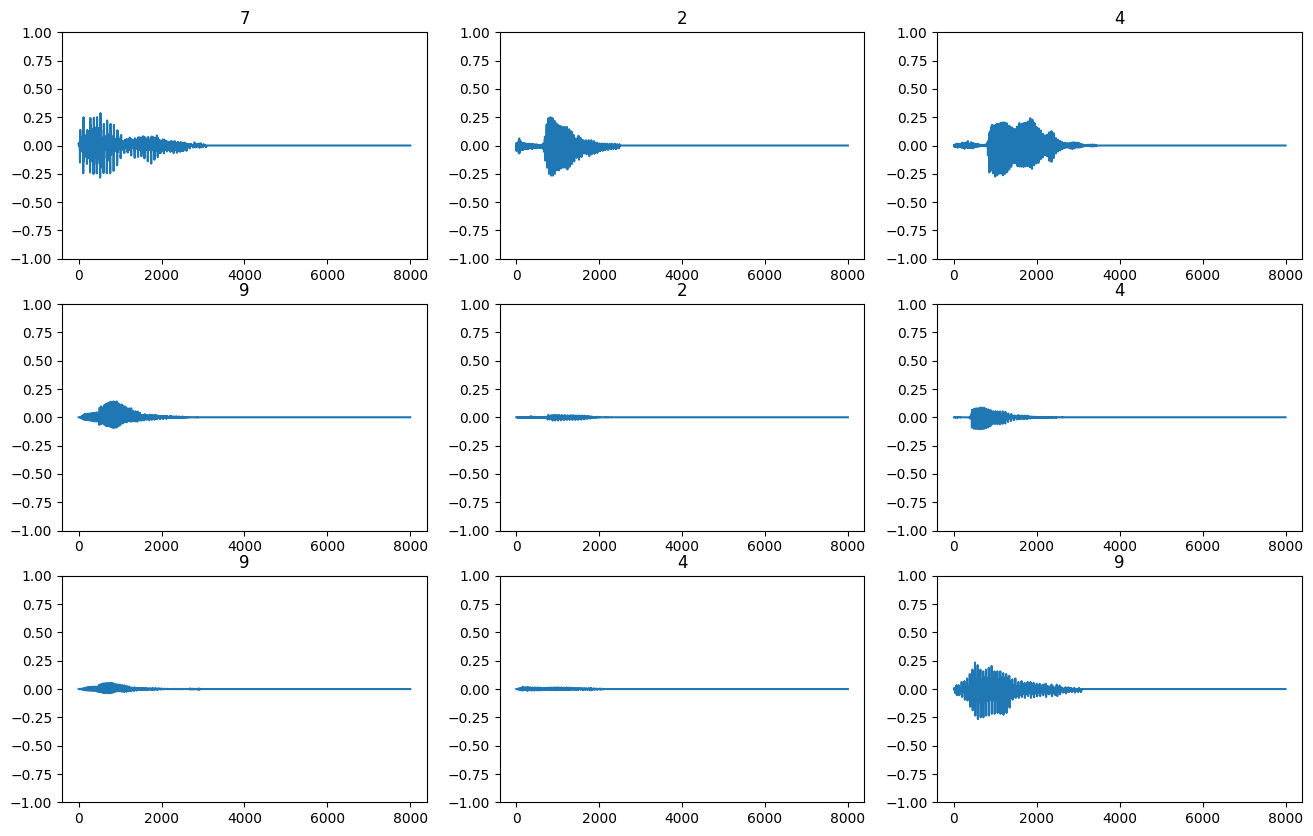

In [ ]:
plt.figure(figsize=(16, 10))
rows = 3
cols = 3
n = rows * cols
for i in range(n):
  plt.subplot(rows, cols, i+1)
  audio_signal = example_audio[i]
  plt.plot(audio_signal)
  plt.title(label_names[example_labels[i]])
  #plt.yticks(np.arange(-7000, 0, 7000))
  plt.ylim([-1, 1])

Observamos que no siempre se utiliza toda la duracion del audio para decir el numero

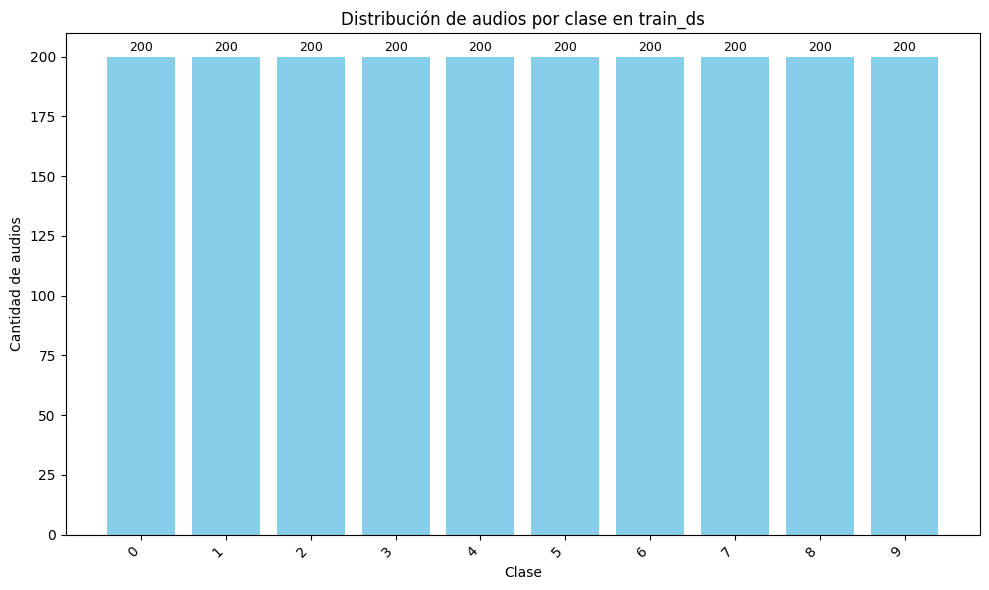

In [ ]:
# Inicializamos contador
cant_clases = {name: 0 for name in train_ds.class_names}

# Recorremos el dataset
for audio, labels in train_ds:
    for label in labels.numpy():  # Convertimos a numpy para facilidad
        class_name = train_ds.class_names[label]
        cant_clases[class_name] += 1

# Visualización
plt.figure(figsize=(10, 6))
bars = plt.bar(cant_clases.keys(), cant_clases.values(), color='skyblue')
plt.xlabel("Clase")
plt.ylabel("Cantidad de audios")
plt.title("Distribución de audios por clase en train_ds")
plt.xticks(rotation=45, ha='right')

# Mostrar los valores arriba de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, str(int(yval)),
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


Podemos observar como el dataset esta totalmente balanceado

# Espectograma

No entiendo para que esto pero si no no funciona

In [ ]:
def squeeze(audio, labels):
  audio = tf.squeeze(audio, axis=-1)
  return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)

for example_audio, example_labels in train_ds.take(1):
  print(example_audio.shape)
  print(example_labels.shape)

(64, 8000)
(64,)


In [ ]:
def get_spectrogram(waveform):
  # Convert the waveform to a spectrogram via a STFT.
  spectrogram = tf.signal.stft(
      waveform, frame_length=255, frame_step=128)
  # Obtain the magnitude of the STFT.
  spectrogram = tf.abs(spectrogram)
  # Add a `channels` dimension, so that the spectrogram can be used
  # as image-like input data with convolution layers (which expect
  # shape (`batch_size`, `height`, `width`, `channels`).
  spectrogram = spectrogram[..., tf.newaxis]
  return spectrogram

In [ ]:
for i in range(3):
  label = label_names[example_labels[i]]
  waveform = example_audio[i]
  spectrogram = get_spectrogram(waveform)

  print('Label:', label)
  print('Waveform shape:', waveform.shape)
  print('Spectrogram shape:', spectrogram.shape)
  print('Audio playback')
  display.display(display.Audio(waveform, rate=8000))

Label: 3
Waveform shape: (8000,)
Spectrogram shape: (61, 129, 1)
Audio playback


Label: 6
Waveform shape: (8000,)
Spectrogram shape: (61, 129, 1)
Audio playback


Label: 8
Waveform shape: (8000,)
Spectrogram shape: (61, 129, 1)
Audio playback


In [ ]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

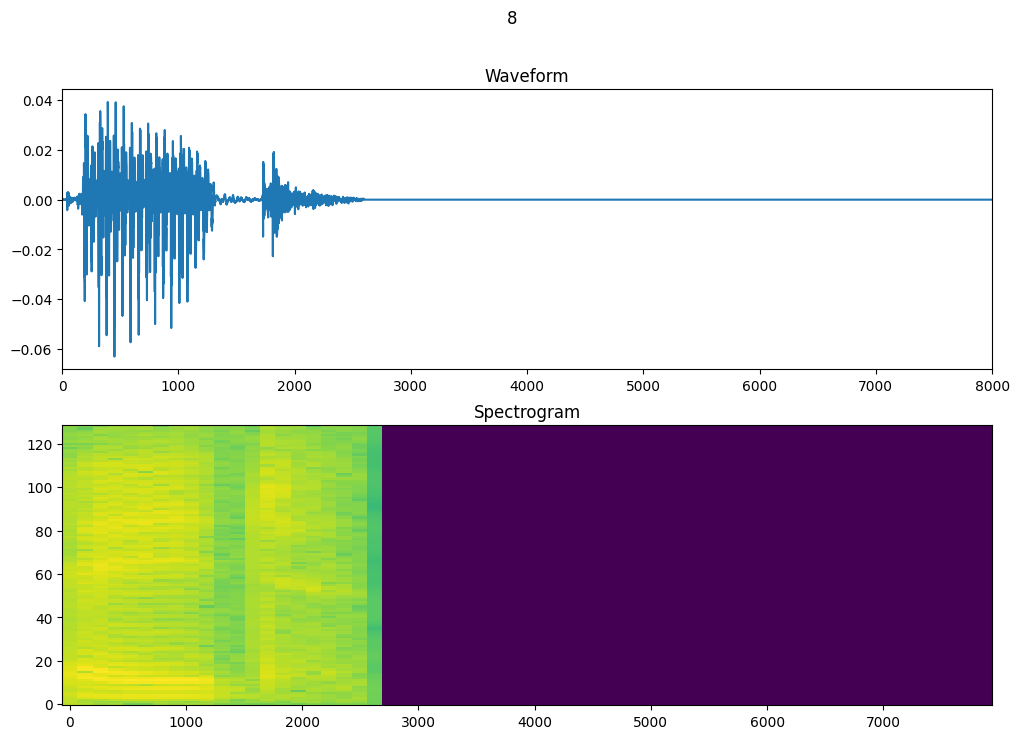

In [ ]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 8000])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(label.title())
plt.show()

Si bien no podemos pretender obtener una comparativa entre el espectograma y el plot, se observa que la sección de audio sin frecuencia esta en violeta.

In [ ]:
def make_spec_ds(ds):
  return ds.map(
      map_func=lambda audio,label: (get_spectrogram(audio), label),
      num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)

In [ ]:
for example_spectrograms, example_spect_labels in train_spectrogram_ds.take(1):
  break

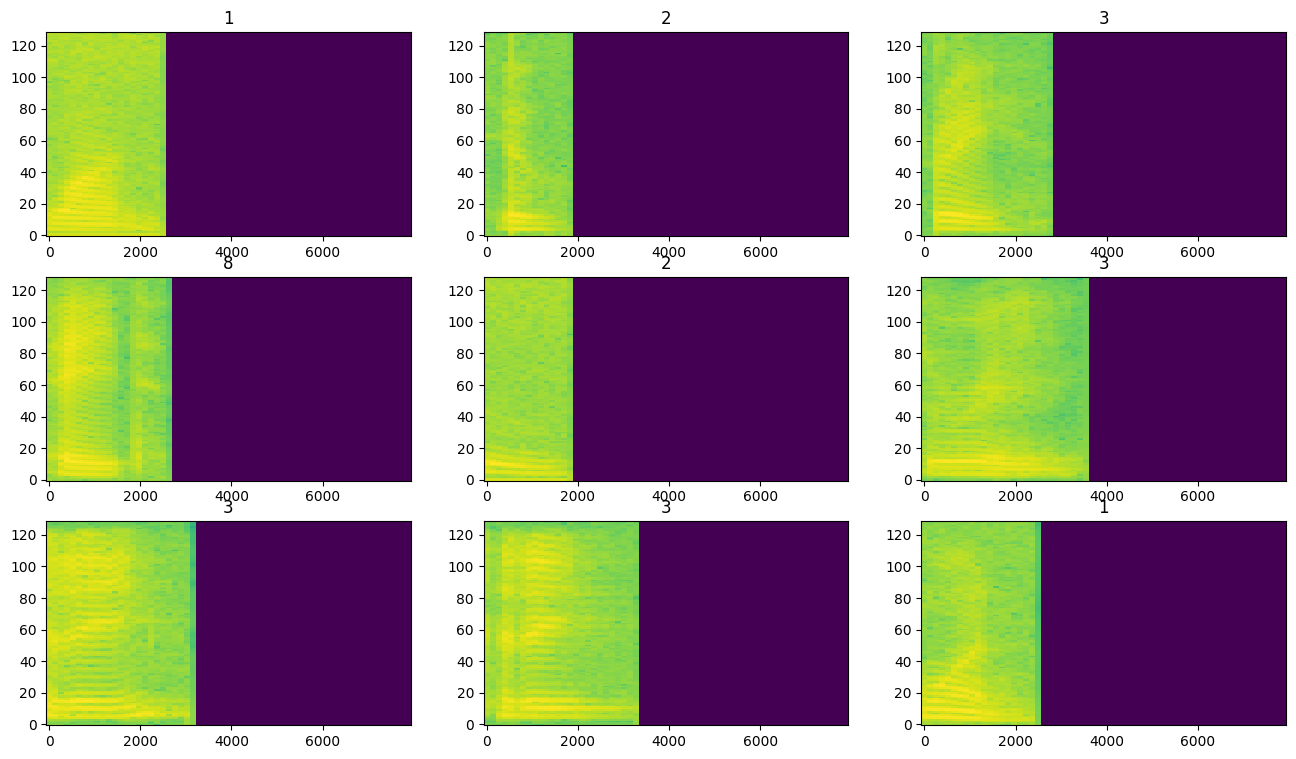

In [ ]:
rows = 3
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))

for i in range(n):
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    plot_spectrogram(example_spectrograms[i].numpy(), ax)
    ax.set_title(label_names[example_spect_labels[i].numpy()])

plt.show()

El espacio en violeta es la zona donde el audio no tienen datos

In [ ]:
train_spectrogram_ds = train_spectrogram_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)

# Modelos

## Modelo con Convulcionales

### Definición del modelo

In [ ]:
input_shape = example_spectrograms.shape[1:]
print('Input shape:', input_shape)
num_labels = len(label_names)

# Instantiate the `tf.keras.layers.Normalization` layer.
norm_layer = layers.Normalization()
# Fit the state of the layer to the spectrograms
# with `Normalization.adapt`.
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),
    # Downsample the input.
    layers.Resizing(32, 32),
    # Normalize.
    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model.summary()

Input shape: (61, 129, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 32, 32, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,869 (6.20 MB)

 Trainable params: 1,625,866 (6.20 MB)

 Non-trainable params: 3 (16.00 B)

### Compilación

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

### Entrenamiento

In [ ]:
EPOCHS = 50
history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    #callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=5),
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 136ms/step - accuracy: 0.2719 - loss: 2.0638 - val_accuracy: 0.6200 - val_loss: 1.2955
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5508 - loss: 1.2947 - val_accuracy: 0.7360 - val_loss: 0.9312
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7002 - loss: 0.9399 - val_accuracy: 0.8380 - val_loss: 0.6817
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7568 - loss: 0.7194 - val_accuracy: 0.8640 - val_loss: 0.5348
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7962 - loss: 0.6261 - val_accuracy: 0.8960 - val_loss: 0.4770
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8360 - loss: 0.5452 - val_accuracy: 0.9280 - val_loss: 0.3289
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8780 - loss: 0.3981 - val_accuracy: 0.9220 - val_loss: 0.3324
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9043 - loss: 0.3423 - val_accuracy: 0.9440 - val_lo

Text(0, 0.5, 'Accuracy [%]')

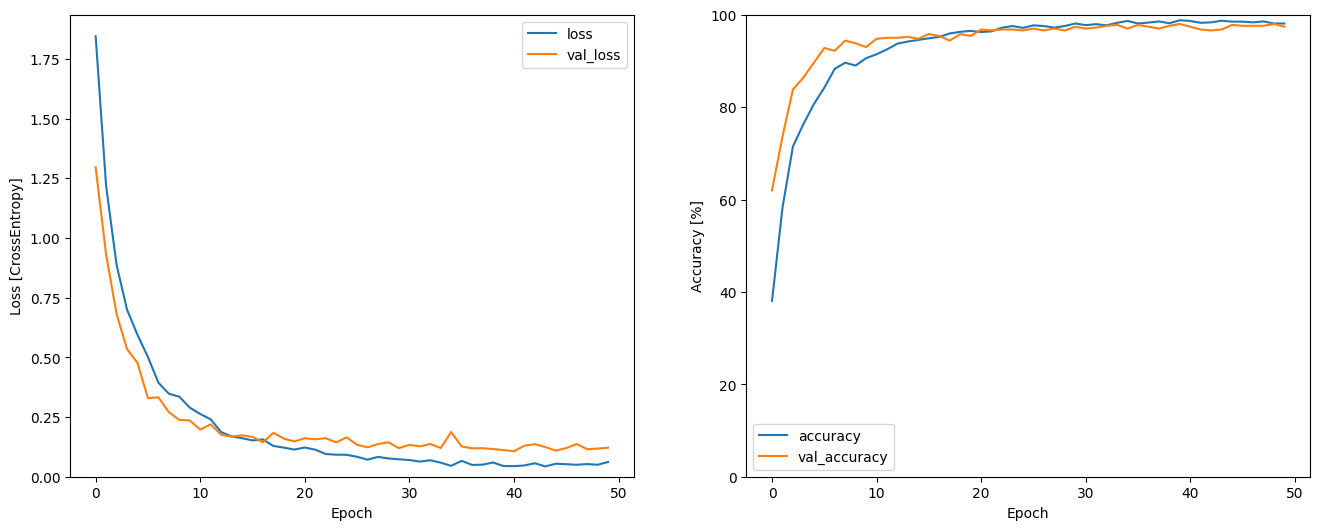

In [ ]:
metrics = history.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.subplot(1,2,2)
plt.plot(history.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')

### Predicción y matriz de confusión

In [ ]:
y_pred = model.predict(val_spectrogram_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step


In [ ]:
y_pred = tf.argmax(y_pred, axis=1)

In [ ]:
y_true = tf.concat(list(val_spectrogram_ds.map(lambda s,lab: lab)), axis=0)

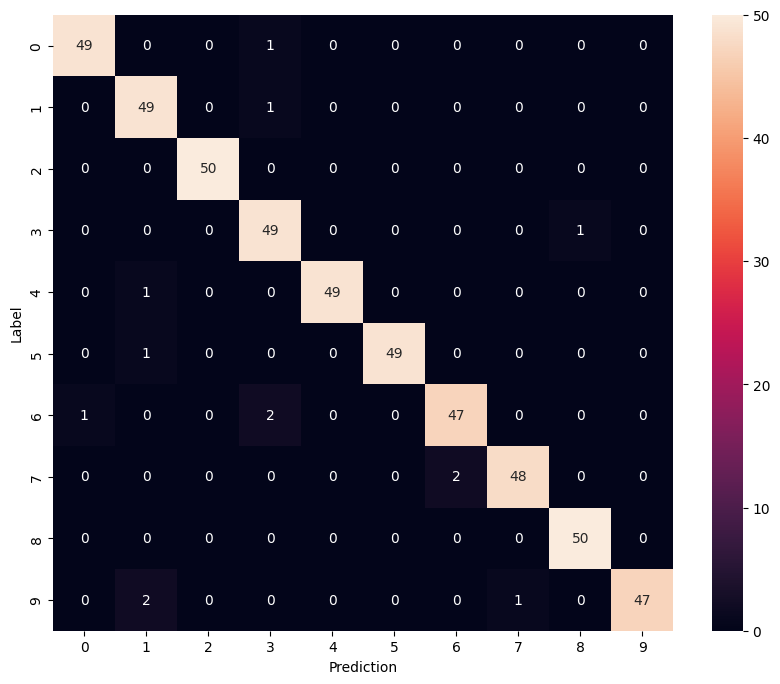

In [ ]:
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

Podemos observar como la diagonal concentra todas las predicciones mostrando este accuracy dado anteriormente del 90%

## Modelo con Recurrentes

### Definición del modelo

In [ ]:
input_shape = example_spectrograms.shape[1:]  # (time_steps, freq_bins, 1)

print('Input shape:', input_shape)
num_labels = len(label_names)

# Normalización
norm_layer = layers.Normalization()
norm_layer.adapt(data=train_spectrogram_ds.map(lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),
    norm_layer,

    # Aplanamos el eje de frecuencia y dejamos el de tiempo para la RNN
    layers.Reshape((input_shape[0], input_shape[1])),

    # RNNs
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(64)),

    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_labels),
])

model.summary()

Input shape: (61, 129, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 61, 129, 1)     │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 61, 129)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 61, 128)        │        99,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,949 (843.55 KB)

 Trainable params: 215,946 (843.54 KB)

 Non-trainable params: 3 (16.00 B)

### Compilación

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

### Entrenamiento

In [ ]:
EPOCHS = 50
history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    #callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=5),
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.2251 - loss: 2.1744 - val_accuracy: 0.6280 - val_loss: 1.3842
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5658 - loss: 1.2635 - val_accuracy: 0.8400 - val_loss: 0.5445
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7942 - loss: 0.6167 - val_accuracy: 0.8540 - val_loss: 0.3907
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8863 - loss: 0.3640 - val_accuracy: 0.9140 - val_loss: 0.2410
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9144 - loss: 0.2626 - val_accuracy: 0.9260 - val_loss: 0.2245
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9361 - loss: 0.1949 - val_accuracy: 0.9700 - val_loss: 0.1262
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9636 - loss: 0.1282 - val_accuracy: 0.9720 - val_loss: 0.1046
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9677 - loss: 0.1111 - val_accuracy: 0.9520 - v

Text(0, 0.5, 'Accuracy [%]')

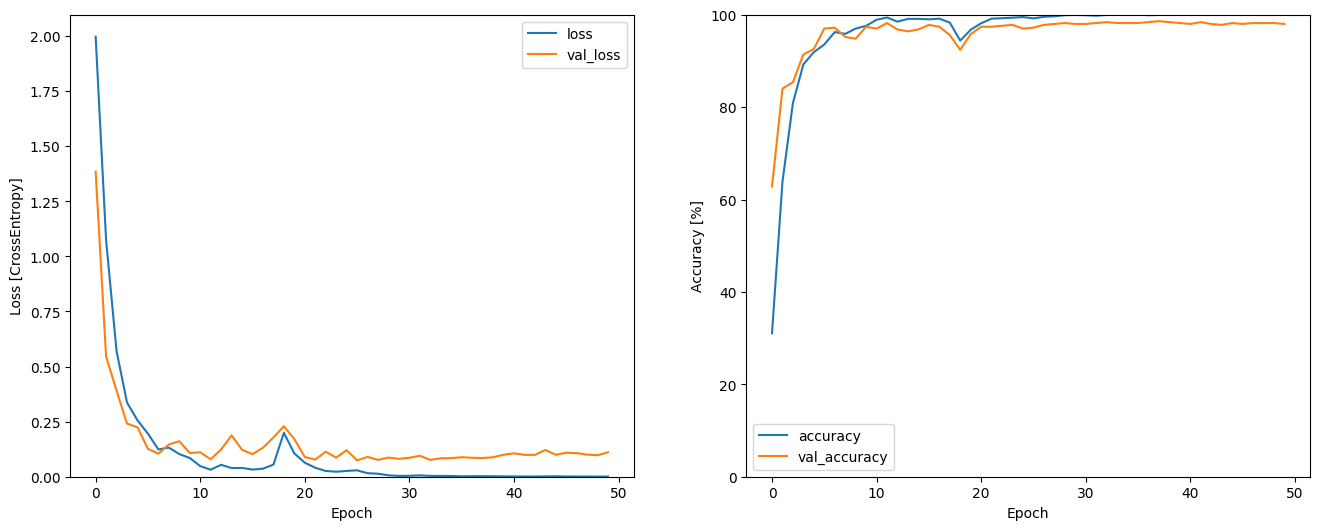

In [ ]:
metrics = history.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.subplot(1,2,2)
plt.plot(history.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')

### Predicción y matriz de confusión

In [ ]:
y_pred = model.predict(val_spectrogram_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step


In [ ]:
y_pred = tf.argmax(y_pred, axis=1)

In [ ]:
y_true = tf.concat(list(val_spectrogram_ds.map(lambda s,lab: lab)), axis=0)

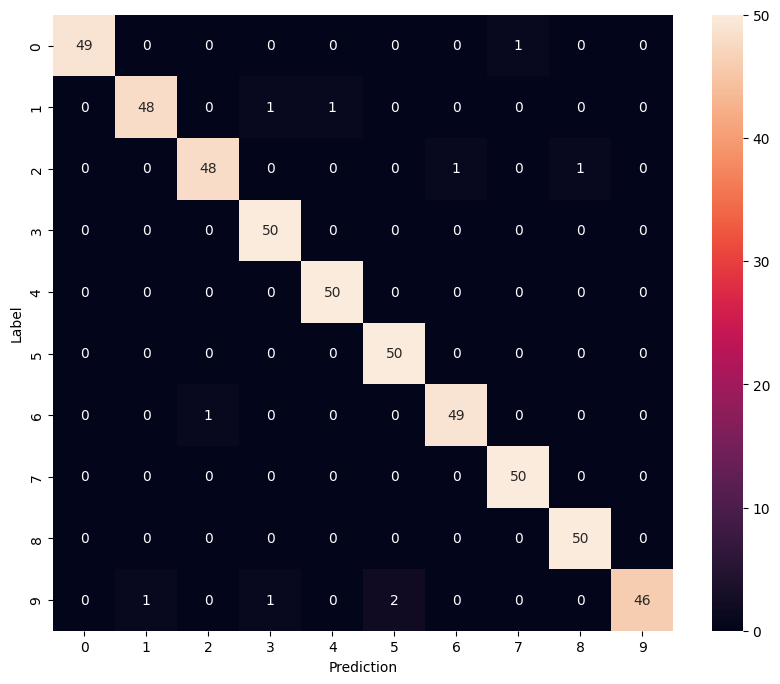

In [ ]:
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

#Conclusiones

Comparar por accuracy que seran lo mismo por ende miramos los parametros y el tiempo de inferencia.

Falta

- Titulos de los graficos
- Conclusiones
- Completar readme
- Comentar los graficos saludos
- Verificar el EDA